
# Election Bloc Change Prediction Project  
## Notebook 04 — Annual Feature Engineering and 2023 Forecast Inputs

### Purpose

This notebook rebuilds the explanatory-variable layer from the raw annual locality files for 2019–2023.

The revised project does not ask only whether locality characteristics explain the **level** of voting. It asks whether locality characteristics and their changes can help explain and predict **change in voting patterns**, beyond the previous-election baseline.

### Main tasks

1. Load the transition panel produced by Notebook 03.
2. Load and harmonize annual locality data for 2019–2023:
   - demographics
   - education
   - income and wages
   - unemployment, benefits and welfare
3. Detect the correct Excel header and locality-code column automatically.
4. Standardize missing values and year-dependent column labels.
5. Engineer consistent income variables across changing source schemas.
6. Create one annual locality-feature table.
7. Align annual features to each election transition:
   - previous-year level
   - current-year level
   - current minus previous change
8. Preserve missing values for training-only preprocessing later.
9. Create a 2023 scenario input table using:
   - Knesset 25 results as the previous election
   - 2022 locality characteristics
   - 2023 locality characteristics
   - 2022→2023 characteristic changes
10. Save a feature manifest that explicitly separates predictors, targets and forbidden leakage columns.

### Main outputs

- `data/interim/locality_annual_features_2019_2023.csv`
- `data/interim/modeling_transition_features.csv`
- `data/interim/forecast_features_2023.csv`
- `data/interim/forecast_cold_start_candidates_2023.csv`
- `reports/tables/annual_source_schema_audit.csv`
- `reports/tables/annual_feature_availability_by_year.csv`
- `reports/tables/transition_feature_merge_audit.csv`
- `reports/tables/training_feature_missingness.csv`
- `reports/summaries/feature_manifest.json`
- `reports/summaries/notebook_04_summary.json`

### Leakage policy

This notebook does **not**:

- impute missing values
- select features using validation or test data
- use current-election results as predictors
- inspect final-test prediction performance

All imputation, missingness filtering and model selection will be fitted on training transitions only in the modeling notebook.


## 1. Imports and repository setup

In [1]:

from pathlib import Path
import json
import os
import re
import shutil
import subprocess
import sys
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 260)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 99

MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]

TRAIN_TRANSITIONS = [
    "K21_to_K22",
    "K22_to_K23",
]

VALIDATION_TRANSITION = "K23_to_K24"
FINAL_TEST_TRANSITION = "K24_to_K25"
FORECAST_SCENARIO_ID = "K25_to_2023_scenario"


In [2]:

REPO_URL = (
    "https://github.com/IfatDav/"
    "Election_Bloc_Prediction_Project.git"
)

DEFAULT_REPO_DIR = Path(
    "/content/Election_Bloc_Prediction_Project"
)


def locate_repository():
    """Locate the project repository or clone it in a fresh Colab runtime."""
    candidates = []

    explicit_root = os.getenv("ELECTION_PROJECT_ROOT")
    if explicit_root:
        candidates.append(Path(explicit_root).expanduser())

    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    candidates.extend([
        DEFAULT_REPO_DIR,
        Path("/content/Election_Bloc_Change_Project"),
    ])

    checked = set()

    for candidate in candidates:
        candidate = candidate.resolve()

        if candidate in checked:
            continue

        checked.add(candidate)

        if (candidate / "data" / "raw").exists():
            return candidate

    if Path("/content").exists():
        if DEFAULT_REPO_DIR.exists():
            shutil.rmtree(DEFAULT_REPO_DIR)

        print("Repository not found locally.")
        print("Cloning the project repository...")

        result = subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(DEFAULT_REPO_DIR),
            ],
            text=True,
            capture_output=True,
        )

        if result.stdout:
            print(result.stdout)

        if result.returncode != 0:
            if result.stderr:
                print(result.stderr)

            raise RuntimeError(
                "Git clone failed. Review the Git output above."
            )

        return DEFAULT_REPO_DIR

    checked_text = "\n".join(
        f"- {path}" for path in checked
    )

    raise FileNotFoundError(
        "Could not locate the project repository.\n"
        f"Checked:\n{checked_text}"
    )


def synchronize_if_missing(repo_root, required_paths):
    """Pull the latest main branch if required files are absent locally."""
    missing = [
        path
        for path in required_paths
        if not path.exists()
    ]

    if not missing:
        return

    if not (repo_root / ".git").exists():
        return

    print("Some required files are missing locally.")
    print("Synchronizing with GitHub...")

    result = subprocess.run(
        [
            "git",
            "-C",
            str(repo_root),
            "pull",
            "--ff-only",
            "origin",
            "main",
        ],
        text=True,
        capture_output=True,
    )

    if result.stdout:
        print(result.stdout)

    if result.returncode != 0:
        if result.stderr:
            print(result.stderr)

        raise RuntimeError(
            "Git pull failed. Restart the runtime or resolve "
            "local repository conflicts."
        )


REPO_ROOT = locate_repository()

RAW_DIR = REPO_ROOT / "data" / "raw"
INTERIM_DIR = REPO_ROOT / "data" / "interim"
REPORTS_DIR = REPO_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
SUMMARIES_DIR = REPORTS_DIR / "summaries"

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

ENRICHED_PANEL_PATH = (
    INTERIM_DIR
    / "election_transition_panel_with_locality_type.csv"
)

NOTEBOOK_03_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_03_summary.json"
)

synchronize_if_missing(
    REPO_ROOT,
    [
        ENRICHED_PANEL_PATH,
        NOTEBOOK_03_SUMMARY_PATH,
    ],
)

print("Repository root:", REPO_ROOT)
print("Notebook 03 panel:", ENRICHED_PANEL_PATH)


Repository not found locally.
Cloning the project repository...
Repository root: /content/Election_Bloc_Prediction_Project
Notebook 03 panel: /content/Election_Bloc_Prediction_Project/data/interim/election_transition_panel_with_locality_type.csv


## 2. Validate Notebook 03 outputs

In [3]:

required_previous_outputs = [
    ENRICHED_PANEL_PATH,
    NOTEBOOK_03_SUMMARY_PATH,
]

missing_previous_outputs = [
    path
    for path in required_previous_outputs
    if not path.exists()
]

if missing_previous_outputs:
    raise FileNotFoundError(
        "Required Notebook 03 outputs are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_previous_outputs
        )
    )

transition_panel = pd.read_csv(
    ENRICHED_PANEL_PATH,
    dtype={"locality_symbol": "string"},
)

with NOTEBOOK_03_SUMMARY_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    notebook_03_summary = json.load(file)

expected_split = notebook_03_summary[
    "experimental_split"
]

actual_counts = (
    transition_panel["transition_id"]
    .value_counts()
    .to_dict()
)

if actual_counts.get(
    FINAL_TEST_TRANSITION,
    0,
) != expected_split["final_test_rows_locked"]:
    raise ValueError(
        "Final-test row count differs from Notebook 03 summary."
    )

duplicate_count = int(
    transition_panel.duplicated(
        ["locality_symbol", "transition_id"]
    ).sum()
)

if duplicate_count:
    raise ValueError(
        f"Found {duplicate_count} duplicated locality-transition rows."
    )

print("Rows loaded:", len(transition_panel))
print(
    "Transitions:",
    actual_counts,
)
print(
    "Notebook 03 best baseline:",
    notebook_03_summary[
        "validation_results"
    ]["best_baseline"],
)
print(
    "Notebook 03 validation MAE:",
    notebook_03_summary[
        "validation_results"
    ]["best_mae"],
)


Rows loaded: 4851
Transitions: {'K22_to_K23': 1214, 'K24_to_K25': 1213, 'K21_to_K22': 1212, 'K23_to_K24': 1212}
Notebook 03 best baseline: Previous-election persistence
Notebook 03 validation MAE: 3.082348420193735



Notebook 03 found that previous-election persistence was the strongest simple validation baseline. The purpose of the new features is therefore to test whether locality characteristics can improve on that benchmark, not merely reproduce stable voting levels.


## 3. Annual source configuration and file inventory

In [4]:

YEARS = list(range(2019, 2024))

SOURCE_CONFIG = {
    "demographic": {
        "folder": RAW_DIR / "Demographic_data",
        "filename": "Demographic_{year}.xlsx",
    },
    "education": {
        "folder": RAW_DIR / "Education_data",
        "filename": "Education_{year}.xlsx",
    },
    "income": {
        "folder": RAW_DIR / "Average_income",
        "filename": "ICBS_{year}.xlsx",
    },
    "welfare": {
        "folder": RAW_DIR / "Unemployment_data",
        "filename": "Unemployment_{year}.xlsx",
    },
}

source_inventory_rows = []

for source_name, config in SOURCE_CONFIG.items():
    for year in YEARS:
        file_path = (
            config["folder"]
            / config["filename"].format(
                year=year
            )
        )

        source_inventory_rows.append({
            "source": source_name,
            "year": year,
            "file_path": str(file_path),
            "exists": file_path.exists(),
        })

source_inventory = pd.DataFrame(
    source_inventory_rows
)

missing_raw_files = source_inventory.loc[
    ~source_inventory["exists"]
]

if not missing_raw_files.empty:
    raise FileNotFoundError(
        "Annual raw files are missing:\n"
        + missing_raw_files[
            "file_path"
        ].to_string(index=False)
    )

source_inventory


,source,year,file_path,exists
0,demographic,2019,/content/Election_Bloc_Prediction_Project/data...,True
1,demographic,2020,/content/Election_Bloc_Prediction_Project/data...,True
2,demographic,2021,/content/Election_Bloc_Prediction_Project/data...,True
3,demographic,2022,/content/Election_Bloc_Prediction_Project/data...,True
4,demographic,2023,/content/Election_Bloc_Prediction_Project/data...,True
5,education,2019,/content/Election_Bloc_Prediction_Project/data...,True
6,education,2020,/content/Election_Bloc_Prediction_Project/data...,True
7,education,2021,/content/Election_Bloc_Prediction_Project/data...,True
8,education,2022,/content/Election_Bloc_Prediction_Project/data...,True
9,education,2023,/content/Election_Bloc_Prediction_Project/data...,True


## 4. Robust Excel-reading utilities

In [5]:

MISSING_TOKENS = {
    "",
    " ",
    "..",
    "...",
    "....",
    "-",
    "--",
    "—",
    "–",
    "לא ידוע",
    "לא רלוונטי",
    "n/a",
    "na",
    "nan",
    "none",
}

LOCALITY_SYMBOL_CANDIDATES = [
    "סמל יישוב",
    "סמל ישוב",
    "סמל היישוב",
    "סמל הישוב",
    "locality_symbol",
    "symbol",
]

LOCALITY_NAME_CANDIDATES = [
    "שם יישוב",
    "שם ישוב",
    "שם היישוב",
    "שם הישוב",
    "locality_name",
]


def clean_text(value):
    if pd.isna(value):
        return ""

    text = str(value)
    text = text.replace("\\ufeff", " ")
    text = text.replace("\\n", " ")
    text = text.replace("\\r", " ")
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\\s+", " ", text)

    return text.strip()


def matching_text(value):
    text = clean_text(value).lower()
    text = text.replace('"', "")
    text = text.replace("'", "")
    text = text.replace("׳", "")
    text = text.replace("״", "")
    text = re.sub(r"[^0-9a-zא-ת]+", "", text)

    return text


def is_locality_symbol_label(value):
    normalized = matching_text(value)

    exact = {
        matching_text(candidate)
        for candidate in LOCALITY_SYMBOL_CANDIDATES
    }

    if normalized in exact:
        return True

    return (
        "סמל" in normalized
        and (
            "יישוב" in normalized
            or "ישוב" in normalized
        )
    )


def is_locality_name_label(value):
    normalized = matching_text(value)

    exact = {
        matching_text(candidate)
        for candidate in LOCALITY_NAME_CANDIDATES
    }

    if normalized in exact:
        return True

    return (
        "שם" in normalized
        and (
            "יישוב" in normalized
            or "ישוב" in normalized
        )
    )


def flatten_columns(columns):
    if isinstance(columns, pd.MultiIndex):
        flattened = []

        for values in columns:
            parts = [
                clean_text(value)
                for value in values
                if clean_text(value)
                and not clean_text(value).lower().startswith(
                    "unnamed"
                )
            ]

            flattened.append(
                " | ".join(parts)
            )

        return flattened

    return [
        clean_text(column)
        for column in columns
    ]


def make_unique(labels):
    counts = {}
    unique_labels = []

    for label in labels:
        base = label or "unnamed"
        count = counts.get(base, 0) + 1
        counts[base] = count

        if count == 1:
            unique_labels.append(base)
        else:
            unique_labels.append(
                f"{base}__duplicate_{count}"
            )

    return unique_labels


def detect_sheet_and_header(file_path, preview_rows=30):
    excel_file = pd.ExcelFile(file_path)

    for sheet_name in excel_file.sheet_names:
        preview = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            header=None,
            nrows=preview_rows,
            dtype=object,
        )

        for row_index, row in preview.iterrows():
            values = [
                value
                for value in row.tolist()
                if not pd.isna(value)
            ]

            if any(
                is_locality_symbol_label(value)
                for value in values
            ):
                return sheet_name, int(row_index)

    raise ValueError(
        "Could not detect a header row containing a locality "
        f"symbol in {file_path}."
    )


def first_matching_column(
    columns,
    matcher,
    required=True,
):
    for column in columns:
        if matcher(column):
            return column

    if required:
        raise KeyError(
            "No matching column was found."
        )

    return None


def to_numeric_series(series):
    text = (
        series.astype("string")
        .str.strip()
        .replace(
            list(MISSING_TOKENS),
            pd.NA,
        )
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("₪", "", regex=False)
        .str.replace("<", "", regex=False)
        .str.replace(">", "", regex=False)
        .str.replace(
            r"^\\((.*)\\)$",
            r"-\\1",
            regex=True,
        )
    )

    return pd.to_numeric(
        text,
        errors="coerce",
    )


def normalize_locality_symbol(series):
    return (
        to_numeric_series(series)
        .astype("Int64")
        .astype("string")
    )


def canonical_feature_label(
    label,
    year,
):
    text = clean_text(label)

    # Remove the file year when it appears as a standalone label token.
    text = re.sub(
        rf"(?<!\\d){year}(?!\\d)",
        " ",
        text,
    )

    text = re.sub(
        r"\\s+",
        " ",
        text,
    )

    text = text.strip(
        " -_/|()[]"
    )

    return text


def read_annual_source(
    file_path,
    source_name,
    year,
):
    sheet_name, header_row = (
        detect_sheet_and_header(
            file_path
        )
    )

    raw = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        header=header_row,
    )

    raw = raw.dropna(
        axis=0,
        how="all",
    ).dropna(
        axis=1,
        how="all",
    )

    raw.columns = make_unique(
        flatten_columns(
            raw.columns
        )
    )

    symbol_column = first_matching_column(
        raw.columns,
        is_locality_symbol_label,
    )

    name_column = first_matching_column(
        raw.columns,
        is_locality_name_label,
        required=False,
    )

    output = pd.DataFrame({
        "locality_symbol": normalize_locality_symbol(
            raw[symbol_column]
        ),
        "year": year,
    })

    if name_column is not None:
        output[
            f"{source_name}__locality_name"
        ] = (
            raw[name_column]
            .astype("string")
            .str.strip()
        )

    identifier_columns = {
        symbol_column,
        name_column,
    }

    feature_audit_rows = []

    for column in raw.columns:
        if column in identifier_columns:
            continue

        if clean_text(column).lower().startswith(
            "unnamed"
        ):
            continue

        numeric_values = to_numeric_series(
            raw[column]
        )

        non_missing_numeric = int(
            numeric_values.notna().sum()
        )

        if non_missing_numeric == 0:
            feature_audit_rows.append({
                "source": source_name,
                "year": year,
                "raw_column": column,
                "canonical_column": pd.NA,
                "numeric_non_missing": 0,
                "kept": False,
                "reason": "no_numeric_values",
            })
            continue

        canonical = canonical_feature_label(
            column,
            year,
        )

        prefixed_name = (
            f"{source_name}__{canonical}"
        )

        if prefixed_name in output.columns:
            duplicate_index = 2
            candidate = (
                f"{prefixed_name}"
                f"__duplicate_{duplicate_index}"
            )

            while candidate in output.columns:
                duplicate_index += 1
                candidate = (
                    f"{prefixed_name}"
                    f"__duplicate_{duplicate_index}"
                )

            prefixed_name = candidate

        output[prefixed_name] = numeric_values

        feature_audit_rows.append({
            "source": source_name,
            "year": year,
            "raw_column": column,
            "canonical_column": prefixed_name,
            "numeric_non_missing": non_missing_numeric,
            "kept": True,
            "reason": "numeric_feature",
        })

    output = output.loc[
        output["locality_symbol"].notna()
    ].copy()

    duplicate_symbols = int(
        output["locality_symbol"]
        .duplicated()
        .sum()
    )

    if duplicate_symbols:
        output = (
            output.groupby(
                [
                    "locality_symbol",
                    "year",
                ],
                as_index=False,
            )
            .first()
        )

    metadata = {
        "source": source_name,
        "year": year,
        "file_path": str(file_path),
        "sheet_name": sheet_name,
        "header_row_zero_based": header_row,
        "rows_after_cleaning": int(
            len(output)
        ),
        "unique_localities": int(
            output[
                "locality_symbol"
            ].nunique()
        ),
        "numeric_features_kept": int(
            sum(
                row["kept"]
                for row
                in feature_audit_rows
            )
        ),
        "duplicate_locality_rows_collapsed": (
            duplicate_symbols
        ),
    }

    return (
        output,
        metadata,
        pd.DataFrame(feature_audit_rows),
    )


## 5. Load all annual source files

In [6]:

annual_source_frames = {}
source_schema_rows = []
source_column_audits = []

for source_name, config in SOURCE_CONFIG.items():
    annual_source_frames[source_name] = {}

    for year in YEARS:
        file_path = (
            config["folder"]
            / config["filename"].format(
                year=year
            )
        )

        (
            source_frame,
            source_metadata,
            source_column_audit,
        ) = read_annual_source(
            file_path=file_path,
            source_name=source_name,
            year=year,
        )

        annual_source_frames[
            source_name
        ][year] = source_frame

        source_schema_rows.append(
            source_metadata
        )

        source_column_audits.append(
            source_column_audit
        )

        print(
            f"{source_name} {year}: "
            f"{len(source_frame)} rows, "
            f"{source_metadata['numeric_features_kept']} "
            "numeric features"
        )

annual_source_schema_audit = (
    pd.DataFrame(
        source_schema_rows
    )
)

annual_source_column_audit = (
    pd.concat(
        source_column_audits,
        ignore_index=True,
    )
)

annual_source_schema_audit


demographic 2019: 193 rows, 59 numeric features
demographic 2020: 201 rows, 65 numeric features
demographic 2021: 201 rows, 65 numeric features
demographic 2022: 202 rows, 58 numeric features
demographic 2023: 193 rows, 59 numeric features
education 2019: 201 rows, 39 numeric features
education 2020: 201 rows, 39 numeric features
education 2021: 201 rows, 39 numeric features
education 2022: 202 rows, 39 numeric features
education 2023: 193 rows, 39 numeric features
income 2019: 224 rows, 13 numeric features
income 2020: 197 rows, 3 numeric features
income 2021: 224 rows, 13 numeric features
income 2022: 226 rows, 13 numeric features
income 2023: 200 rows, 13 numeric features
welfare 2019: 224 rows, 30 numeric features
welfare 2020: 224 rows, 30 numeric features
welfare 2021: 224 rows, 30 numeric features
welfare 2022: 225 rows, 29 numeric features
welfare 2023: 226 rows, 29 numeric features


,source,year,file_path,sheet_name,header_row_zero_based,rows_after_cleaning,unique_localities,numeric_features_kept,duplicate_locality_rows_collapsed
0,demographic,2019,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,193,193,59,0
1,demographic,2020,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,201,201,65,0
2,demographic,2021,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,201,201,65,0
3,demographic,2022,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,202,202,58,0
4,demographic,2023,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,193,193,59,0
5,education,2019,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,201,201,39,0
6,education,2020,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,201,201,39,0
7,education,2021,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,201,201,39,0
8,education,2022,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,202,202,39,0
9,education,2023,/content/Election_Bloc_Prediction_Project/data...,גיליון1,0,193,193,39,0



## 6. Harmonize changing income schemas

The income source changes structure across years. The notebook therefore creates a small set of consistent engineered variables:

- total average monthly wage
- men's average monthly wage
- women's average monthly wage
- male/female wage ratio
- share earning below or up to minimum wage
- 2019 wage Gini, retained as a declared static historical attribute

The raw numeric income columns remain available for audit, but the standardized variables are the preferred income predictors.


In [7]:

def normalized_column_text(column):
    return matching_text(
        column.split(
            "__",
            1,
        )[-1]
    )


def candidate_columns(
    frame,
    include_all=None,
    include_any=None,
    exclude_any=None,
):
    include_all = include_all or []
    include_any = include_any or []
    exclude_any = exclude_any or []

    matches = []

    for column in frame.columns:
        if column in {
            "locality_symbol",
            "year",
        }:
            continue

        text = normalized_column_text(
            column
        )

        if include_all and not all(
            token in text
            for token in include_all
        ):
            continue

        if include_any and not any(
            token in text
            for token in include_any
        ):
            continue

        if exclude_any and any(
            token in text
            for token in exclude_any
        ):
            continue

        matches.append(column)

    return matches


def choose_column(
    frame,
    include_all=None,
    include_any=None,
    exclude_any=None,
    preferred_tokens=None,
):
    candidates = candidate_columns(
        frame,
        include_all=include_all,
        include_any=include_any,
        exclude_any=exclude_any,
    )

    if not candidates:
        return None

    preferred_tokens = (
        preferred_tokens
        or []
    )

    def score(column):
        text = normalized_column_text(
            column
        )

        return sum(
            token in text
            for token in preferred_tokens
        )

    candidates = sorted(
        candidates,
        key=lambda column: (
            -score(column),
            len(column),
        ),
    )

    return candidates[0]


def standardize_income_frame(
    frame,
    year,
):
    output = frame[
        [
            "locality_symbol",
            "year",
        ]
    ].copy()

    total_wage_column = choose_column(
        frame,
        include_all=[
            "שכרממוצע",
        ],
        exclude_any=[
            "גברים",
            "גבר",
            "זכרים",
            "נשים",
            "אישה",
            "נקבות",
        ],
        preferred_tokens=[
            "כלל",
            "סהכ",
            "שכירים",
            "בעליהכנסה",
        ],
    )

    male_wage_column = choose_column(
        frame,
        include_all=[
            "שכרממוצע",
        ],
        include_any=[
            "גברים",
            "גבר",
            "זכרים",
        ],
    )

    female_wage_column = choose_column(
        frame,
        include_all=[
            "שכרממוצע",
        ],
        include_any=[
            "נשים",
            "אישה",
            "נקבות",
        ],
    )

    direct_minimum_wage_pct = choose_column(
        frame,
        include_all=[
            "אחוז",
        ],
        include_any=[
            "שכרמינימום",
            "מינימום",
        ],
    )

    below_minimum_count = choose_column(
        frame,
        include_any=[
            "מתחתלשכרהמינימום",
            "עדשכרמינימום",
        ],
        preferred_tokens=[
            "מספר",
        ],
        exclude_any=[
            "אחוז",
        ],
    )

    income_earner_count = choose_column(
        frame,
        include_any=[
            "בעליהכנסהמשכר",
            "שכירים",
        ],
        preferred_tokens=[
            "מספר",
            "כלל",
        ],
        exclude_any=[
            "מינימום",
            "שכרממוצע",
            "אחוז",
        ],
    )

    gini_column = choose_column(
        frame,
        include_any=[
            "גיני",
            "איהשוויון",
        ],
    )

    source_matches = {
        "avg_monthly_wage_total": (
            total_wage_column
        ),
        "avg_monthly_wage_men": (
            male_wage_column
        ),
        "avg_monthly_wage_women": (
            female_wage_column
        ),
        "pct_below_minimum_wage_direct": (
            direct_minimum_wage_pct
        ),
        "below_minimum_wage_count": (
            below_minimum_count
        ),
        "income_earner_count": (
            income_earner_count
        ),
        "gini_wage": gini_column,
    }

    for output_name, source_column in (
        source_matches.items()
    ):
        if source_column is None:
            output[
                f"income_standard__{output_name}"
            ] = np.nan
        else:
            output[
                f"income_standard__{output_name}"
            ] = frame[
                source_column
            ]

    men_wage = pd.to_numeric(
        output[
            "income_standard__avg_monthly_wage_men"
        ],
        errors="coerce",
    ).astype("float64")

    women_wage = pd.to_numeric(
        output[
            "income_standard__avg_monthly_wage_women"
        ],
        errors="coerce",
    ).astype("float64")

    output[
        "income_standard__gender_wage_ratio"
    ] = men_wage.div(
        women_wage.where(
            women_wage > 0
        )
    )

    below_minimum_count_values = pd.to_numeric(
        output[
            "income_standard__below_minimum_wage_count"
        ],
        errors="coerce",
    ).astype("float64")

    income_earner_count_values = pd.to_numeric(
        output[
            "income_standard__income_earner_count"
        ],
        errors="coerce",
    ).astype("float64")

    derived_minimum_pct = (
        below_minimum_count_values
        .div(
            income_earner_count_values.where(
                income_earner_count_values > 0
            )
        )
        .mul(100)
    )

    direct_minimum_pct_values = pd.to_numeric(
        output[
            "income_standard__pct_below_minimum_wage_direct"
        ],
        errors="coerce",
    ).astype("float64")

    output[
        "income_standard__pct_below_minimum_wage"
    ] = direct_minimum_pct_values.fillna(
        derived_minimum_pct
    )

    match_audit = pd.DataFrame([
        {
            "year": year,
            "standardized_feature": key,
            "matched_raw_column": value,
        }
        for key, value
        in source_matches.items()
    ])

    return output, match_audit


standardized_income_frames = []
income_schema_match_audits = []

for year in YEARS:
    standardized_income, match_audit = (
        standardize_income_frame(
            annual_source_frames[
                "income"
            ][year],
            year,
        )
    )

    standardized_income_frames.append(
        standardized_income
    )

    income_schema_match_audits.append(
        match_audit
    )

income_standard_long = pd.concat(
    standardized_income_frames,
    ignore_index=True,
)

income_schema_match_audit = pd.concat(
    income_schema_match_audits,
    ignore_index=True,
)

income_schema_match_audit


/tmp/ipykernel_1480/2600119587.py:334: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  income_standard_long = pd.concat(


,year,standardized_feature,matched_raw_column
0,2019,avg_monthly_wage_total,"income__שכר ממוצע לחודש של שכירים (ש""ח) כלל הש..."
1,2019,avg_monthly_wage_men,"income__שכר ממוצע לחודש של שכירים (ש""ח) גברים"
2,2019,avg_monthly_wage_women,"income__שכר ממוצע לחודש של שכירים (ש""ח) נשים"
3,2019,pct_below_minimum_wage_direct,income__אחוז השכירים המשתכרים עד שכר מינימום
4,2019,below_minimum_wage_count,None
5,2019,income_earner_count,income__מספר השכירים
6,2019,gini_wage,"income__מדד אי-השוויון שכירים (מדד ג'יני, 0 שו..."
7,2020,avg_monthly_wage_total,"income__שכר ממוצע לחודש של שכירים (ש""ח) כלל הש..."
8,2020,avg_monthly_wage_men,"income__שכר ממוצע לחודש של שכירים (ש""ח) גברים"
9,2020,avg_monthly_wage_women,"income__שכר ממוצע לחודש של שכירים (ש""ח) נשים"


In [8]:

# Retain the 2019 Gini value as an explicitly historical static feature.
gini_2019 = (
    income_standard_long.loc[
        income_standard_long["year"].eq(
            2019
        ),
        [
            "locality_symbol",
            "income_standard__gini_wage",
        ],
    ]
    .rename(
        columns={
            "income_standard__gini_wage": (
                "income_standard__gini_wage_2019_static"
            )
        }
    )
    .drop_duplicates(
        subset=["locality_symbol"]
    )
)

income_standard_long = (
    income_standard_long.merge(
        gini_2019,
        on="locality_symbol",
        how="left",
        validate="many_to_one",
    )
)

income_standard_long[
    [
        "year",
        "income_standard__avg_monthly_wage_total",
        "income_standard__gender_wage_ratio",
        "income_standard__pct_below_minimum_wage",
        "income_standard__gini_wage_2019_static",
    ]
].groupby("year").count()


,income_standard__avg_monthly_wage_total,income_standard__gender_wage_ratio,income_standard__pct_below_minimum_wage,income_standard__gini_wage_2019_static
year,,,,
2019,224,224,224,224
2020,197,197,0,197
2021,224,224,224,224
2022,225,225,225,224
2023,200,200,200,198


## 7. Combine each source across years

In [9]:

source_long_tables = {}

for source_name in SOURCE_CONFIG:
    source_long_tables[
        source_name
    ] = pd.concat(
        [
            annual_source_frames[
                source_name
            ][year]
            for year in YEARS
        ],
        ignore_index=True,
        sort=False,
    )

# Add standardized income features and remove their duplicate key columns.
source_long_tables[
    "income"
] = source_long_tables[
    "income"
].merge(
    income_standard_long,
    on=[
        "locality_symbol",
        "year",
    ],
    how="left",
    validate="one_to_one",
)

for source_name, frame in (
    source_long_tables.items()
):
    duplicate_keys = int(
        frame.duplicated(
            [
                "locality_symbol",
                "year",
            ]
        ).sum()
    )

    if duplicate_keys:
        raise ValueError(
            f"{source_name}: found {duplicate_keys} duplicated "
            "locality-year rows after harmonization."
        )

    print(
        source_name,
        frame.shape,
    )


demographic (990, 71)
education (998, 42)
income (1071, 39)
welfare (1123, 33)



## 8. Build the annual locality-feature table

The merge uses an outer join so that coverage gaps remain visible.

Source-specific locality-name columns are retained only for auditing. They are not candidate model features.


In [10]:

annual_features = None
annual_merge_audit_rows = []

for source_name in [
    "demographic",
    "education",
    "income",
    "welfare",
]:
    source_frame = source_long_tables[
        source_name
    ].copy()

    source_keys = source_frame[
        [
            "locality_symbol",
            "year",
        ]
    ].drop_duplicates()

    if annual_features is None:
        annual_features = source_frame
    else:
        before_rows = len(
            annual_features
        )

        annual_features = (
            annual_features.merge(
                source_frame,
                on=[
                    "locality_symbol",
                    "year",
                ],
                how="outer",
                validate="one_to_one",
            )
        )

        annual_merge_audit_rows.append({
            "source_added": source_name,
            "rows_before": before_rows,
            "source_rows": len(source_frame),
            "rows_after": len(annual_features),
        })

annual_features = annual_features.sort_values(
    [
        "year",
        "locality_symbol",
    ],
    key=lambda series: (
        pd.to_numeric(
            series,
            errors="coerce",
        )
        if series.name == "locality_symbol"
        else series
    ),
).reset_index(drop=True)

annual_merge_audit = pd.DataFrame(
    annual_merge_audit_rows
)

annual_features.shape


(1126, 179)

## 9. Engineer selected welfare rates per 1,000 residents

In [11]:

def find_feature_column(
    columns,
    source_prefix,
    include_all=None,
    include_any=None,
    exclude_any=None,
):
    include_all = include_all or []
    include_any = include_any or []
    exclude_any = exclude_any or []

    candidates = []

    for column in columns:
        if not column.startswith(
            f"{source_prefix}__"
        ):
            continue

        text = normalized_column_text(
            column
        )

        if include_all and not all(
            token in text
            for token in include_all
        ):
            continue

        if include_any and not any(
            token in text
            for token in include_any
        ):
            continue

        if exclude_any and any(
            token in text
            for token in exclude_any
        ):
            continue

        candidates.append(column)

    if not candidates:
        return None

    return sorted(
        candidates,
        key=len,
    )[0]


population_column = find_feature_column(
    annual_features.columns,
    "demographic",
    include_any=[
        "סהכאוכלוסייהבסוףהשנה",
        "אוכלוסייהבסוףהשנה",
        "סהכאוכלוסיהבסוףהשנה",
    ],
    exclude_any=[
        "אחוז",
        "שיעור",
    ],
)

large_family_child_count_column = (
    find_feature_column(
        annual_features.columns,
        "welfare",
        include_all=[
            "5ילדיםויותר",
        ],
        include_any=[
            "מספרילדים",
            "קצבאותילדים",
        ],
        exclude_any=[
            "אחוז",
        ],
    )
)

welfare_rate_audit_rows = []

if (
    population_column is not None
    and large_family_child_count_column
    is not None
):
    engineered_name = (
        "welfare_engineered__children_in_families_"
        "with_5plus_children_per_1000"
    )

    population_values = pd.to_numeric(
        annual_features[
            population_column
        ],
        errors="coerce",
    ).astype("float64")

    large_family_child_count_values = pd.to_numeric(
        annual_features[
            large_family_child_count_column
        ],
        errors="coerce",
    ).astype("float64")

    annual_features[
        engineered_name
    ] = (
        large_family_child_count_values
        .div(
            population_values.where(
                population_values > 0
            )
        )
        .mul(1000)
    )

    welfare_rate_audit_rows.append({
        "engineered_feature": engineered_name,
        "numerator": (
            large_family_child_count_column
        ),
        "denominator": population_column,
        "status": "created",
    })
else:
    welfare_rate_audit_rows.append({
        "engineered_feature": (
            "welfare_engineered__children_in_families_"
            "with_5plus_children_per_1000"
        ),
        "numerator": (
            large_family_child_count_column
        ),
        "denominator": population_column,
        "status": "not_created_missing_source_column",
    })

welfare_rate_audit = pd.DataFrame(
    welfare_rate_audit_rows
)

welfare_rate_audit


,engineered_feature,numerator,denominator,status
0,welfare_engineered__children_in_families_with_...,welfare__מספר ילדים שבגינם שולמו קצבאות במשפחו...,"demographic__סה""כ אוכלוסייה בסוף השנה",created


## 10. Annual feature availability audit

In [12]:

NON_FEATURE_COLUMNS = {
    "locality_symbol",
    "year",
}

NAME_COLUMNS = [
    column
    for column in annual_features.columns
    if column.endswith(
        "__locality_name"
    )
]

ANNUAL_FEATURE_COLUMNS = [
    column
    for column in annual_features.columns
    if (
        column
        not in NON_FEATURE_COLUMNS
        and column
        not in NAME_COLUMNS
    )
]

availability_rows = []

for feature in ANNUAL_FEATURE_COLUMNS:
    source = feature.split(
        "__",
        1,
    )[0]

    for year in YEARS:
        year_mask = (
            annual_features["year"]
            .eq(year)
        )

        non_missing = int(
            annual_features.loc[
                year_mask,
                feature,
            ].notna().sum()
        )

        total_rows = int(
            year_mask.sum()
        )

        availability_rows.append({
            "feature": feature,
            "source": source,
            "year": year,
            "non_missing_rows": non_missing,
            "total_locality_rows": total_rows,
            "availability_pct": (
                non_missing
                / total_rows
                * 100
                if total_rows
                else np.nan
            ),
        })

annual_feature_availability = (
    pd.DataFrame(
        availability_rows
    )
)

feature_year_presence = (
    annual_feature_availability.assign(
        available=lambda frame: (
            frame["non_missing_rows"] > 0
        )
    )
    .pivot_table(
        index=[
            "feature",
            "source",
        ],
        columns="year",
        values="available",
        aggfunc="max",
        fill_value=False,
    )
    .reset_index()
)

feature_year_presence[
    "years_available"
] = feature_year_presence[
    YEARS
].sum(axis=1)

feature_year_presence[
    "available_all_2019_2023"
] = feature_year_presence[
    "years_available"
].eq(len(YEARS))

feature_year_presence[
    "available_2022_and_2023"
] = (
    feature_year_presence[2022]
    & feature_year_presence[2023]
)

feature_year_presence.sort_values(
    [
        "available_2022_and_2023",
        "years_available",
        "source",
        "feature",
    ],
    ascending=[
        False,
        False,
        True,
        True,
    ],
).head(30)


year,feature,source,2019,2020,2021,2022,2023,years_available,available_all_2019_2023,available_2022_and_2023
7,demographic__אחוז באוכלוסייה בסוף השנה בני 14-10,demographic,True,True,True,True,True,5,True,True
8,demographic__אחוז באוכלוסייה בסוף השנה בני 17-0,demographic,True,True,True,True,True,5,True,True
9,demographic__אחוז באוכלוסייה בסוף השנה בני 19-15,demographic,True,True,True,True,True,5,True,True
10,demographic__אחוז באוכלוסייה בסוף השנה בני 29-20,demographic,True,True,True,True,True,5,True,True
11,demographic__אחוז באוכלוסייה בסוף השנה בני 4-0,demographic,True,True,True,True,True,5,True,True
12,demographic__אחוז באוכלוסייה בסוף השנה בני 44-30,demographic,True,True,True,True,True,5,True,True
13,demographic__אחוז באוכלוסייה בסוף השנה בני 59-45,demographic,True,True,True,True,True,5,True,True
14,demographic__אחוז באוכלוסייה בסוף השנה בני 64-60,demographic,True,True,True,True,True,5,True,True
15,demographic__אחוז באוכלוסייה בסוף השנה בני 65 ...,demographic,True,True,True,True,True,5,True,True
16,demographic__אחוז באוכלוסייה בסוף השנה בני 75 ...,demographic,True,True,True,True,True,5,True,True


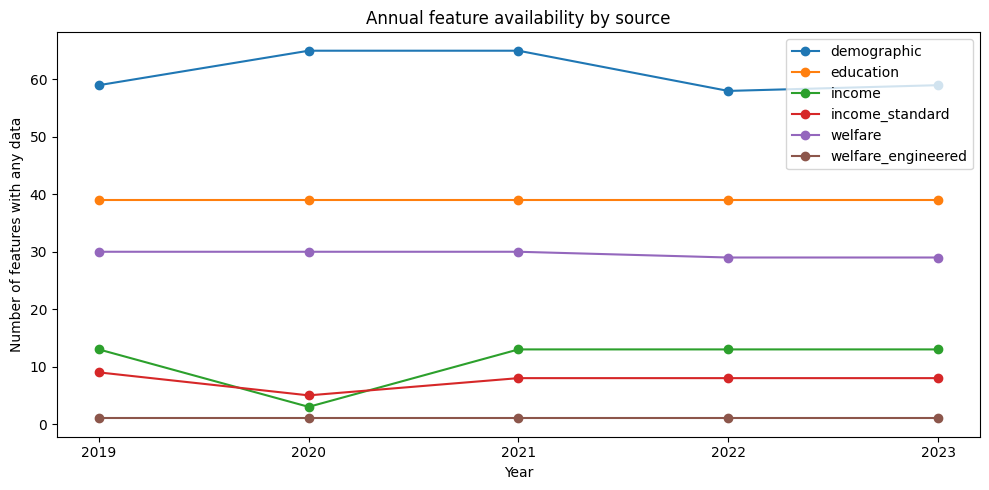

Figure saved to: /content/Election_Bloc_Prediction_Project/reports/figures/annual_feature_availability.png


In [13]:

features_by_source_year = (
    annual_feature_availability.assign(
        feature_available=lambda frame: (
            frame["non_missing_rows"] > 0
        )
    )
    .groupby(
        [
            "source",
            "year",
        ],
        as_index=False,
    )["feature_available"]
    .sum()
    .rename(
        columns={
            "feature_available": (
                "features_with_any_data"
            )
        }
    )
)

figure, axis = plt.subplots(
    figsize=(10, 5),
)

for source_name, group in (
    features_by_source_year.groupby(
        "source"
    )
):
    axis.plot(
        group["year"],
        group[
            "features_with_any_data"
        ],
        marker="o",
        label=source_name,
    )

axis.set_title(
    "Annual feature availability by source"
)
axis.set_xlabel("Year")
axis.set_ylabel(
    "Number of features with any data"
)
axis.set_xticks(YEARS)
axis.legend()

plt.tight_layout()

FEATURE_AVAILABILITY_FIGURE_PATH = (
    FIGURES_DIR
    / "annual_feature_availability.png"
)

plt.savefig(
    FEATURE_AVAILABILITY_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    FEATURE_AVAILABILITY_FIGURE_PATH,
)



## 11. Align annual features to election transitions

For each locality transition, the notebook creates:

- `previous_feature__...`: locality characteristic in the previous election year
- `current_feature__...`: locality characteristic in the current election year
- `delta_feature__...`: current minus previous characteristic

For K21→K22, both elections took place in 2019. Therefore, annual demographic deltas are expected to be zero whenever the feature is observed in 2019.

This is a real limitation of the available time structure and will be reported explicitly.


In [14]:

annual_core = annual_features[
    [
        "locality_symbol",
        "year",
        *ANNUAL_FEATURE_COLUMNS,
    ]
].copy()


def prefix_annual_feature_columns(
    frame,
    prefix,
    year_column_name,
):
    rename_map = {
        "year": year_column_name,
    }

    for feature in ANNUAL_FEATURE_COLUMNS:
        rename_map[
            feature
        ] = (
            f"{prefix}_feature__{feature}"
        )

    return frame.rename(
        columns=rename_map
    )


previous_annual = (
    prefix_annual_feature_columns(
        annual_core,
        prefix="previous",
        year_column_name="previous_year",
    )
)

current_annual = (
    prefix_annual_feature_columns(
        annual_core,
        prefix="current",
        year_column_name="current_year",
    )
)

modeling_transition_features = (
    transition_panel.merge(
        previous_annual,
        on=[
            "locality_symbol",
            "previous_year",
        ],
        how="left",
        validate="many_to_one",
        indicator=(
            "_previous_feature_merge"
        ),
    )
    .merge(
        current_annual,
        on=[
            "locality_symbol",
            "current_year",
        ],
        how="left",
        validate="many_to_one",
        indicator=(
            "_current_feature_merge"
        ),
    )
)

previous_feature_columns = [
    f"previous_feature__{feature}"
    for feature in ANNUAL_FEATURE_COLUMNS
]

current_feature_columns = [
    f"current_feature__{feature}"
    for feature in ANNUAL_FEATURE_COLUMNS
]

delta_feature_columns = []

for feature in ANNUAL_FEATURE_COLUMNS:
    previous_column = (
        f"previous_feature__{feature}"
    )

    current_column = (
        f"current_feature__{feature}"
    )

    delta_column = (
        f"delta_feature__{feature}"
    )

    modeling_transition_features[
        delta_column
    ] = (
        modeling_transition_features[
            current_column
        ]
        - modeling_transition_features[
            previous_column
        ]
    )

    delta_feature_columns.append(
        delta_column
    )

modeling_transition_features[
    "has_previous_annual_features"
] = (
    modeling_transition_features[
        "_previous_feature_merge"
    ].eq("both")
)

modeling_transition_features[
    "has_current_annual_features"
] = (
    modeling_transition_features[
        "_current_feature_merge"
    ].eq("both")
)

modeling_transition_features[
    "has_complete_annual_pair"
] = (
    modeling_transition_features[
        "has_previous_annual_features"
    ]
    & modeling_transition_features[
        "has_current_annual_features"
    ]
)

transition_feature_merge_audit = (
    modeling_transition_features.groupby(
        "transition_id",
        as_index=False,
    ).agg(
        rows=(
            "locality_symbol",
            "size",
        ),
        previous_annual_match_rows=(
            "has_previous_annual_features",
            "sum",
        ),
        current_annual_match_rows=(
            "has_current_annual_features",
            "sum",
        ),
        complete_annual_pair_rows=(
            "has_complete_annual_pair",
            "sum",
        ),
    )
)

transition_feature_merge_audit[
    "complete_pair_coverage_pct"
] = (
    transition_feature_merge_audit[
        "complete_annual_pair_rows"
    ]
    / transition_feature_merge_audit[
        "rows"
    ]
    * 100
)

transition_feature_merge_audit


,transition_id,rows,previous_annual_match_rows,current_annual_match_rows,complete_annual_pair_rows,complete_pair_coverage_pct
0,K21_to_K22,1212,225,225,225,18.564356
1,K22_to_K23,1214,225,224,224,18.451400
2,K23_to_K24,1212,224,224,224,18.481848
3,K24_to_K25,1213,224,225,224,18.466612


## 12. Verify same-year deltas for K21→K22

In [15]:

same_year_rows = (
    modeling_transition_features[
        "transition_id"
    ].eq("K21_to_K22")
)

same_year_delta_values = (
    modeling_transition_features.loc[
        same_year_rows,
        delta_feature_columns,
    ]
)

observed_same_year_deltas = (
    same_year_delta_values.stack(
        future_stack=True
    )
)

max_same_year_delta = (
    float(
        observed_same_year_deltas.abs().max()
    )
    if not observed_same_year_deltas.empty
    else np.nan
)

print(
    "Maximum observed annual-feature delta "
    "for K21→K22:",
    max_same_year_delta,
)

if (
    not np.isnan(max_same_year_delta)
    and max_same_year_delta > 1e-10
):
    raise ValueError(
        "K21→K22 uses the same annual year, but non-zero "
        "annual-feature deltas were found."
    )


Maximum observed annual-feature delta for K21→K22: 0.0



## 13. Training-only missingness audit

This table measures feature missingness using only K21→K22 and K22→K23.

It does not remove any feature. The missingness threshold and imputer will be fitted later inside the training pipeline.


In [16]:

candidate_model_feature_columns = [
    *previous_feature_columns,
    *current_feature_columns,
    *delta_feature_columns,
]

training_mask = (
    modeling_transition_features[
        "transition_id"
    ].isin(TRAIN_TRANSITIONS)
)

training_feature_missingness = (
    modeling_transition_features.loc[
        training_mask,
        candidate_model_feature_columns,
    ]
    .isna()
    .mean()
    .mul(100)
    .rename(
        "training_missing_pct"
    )
    .reset_index()
    .rename(
        columns={
            "index": "feature",
        }
    )
)

training_feature_missingness[
    "feature_role"
] = (
    training_feature_missingness[
        "feature"
    ]
    .str.extract(
        r"^(previous_feature|current_feature|delta_feature)"
    )
)

training_feature_missingness[
    "source"
] = (
    training_feature_missingness[
        "feature"
    ]
    .str.extract(
        r"feature__([^_]+)__"
    )
)

training_feature_missingness = (
    training_feature_missingness.sort_values(
        [
            "training_missing_pct",
            "feature",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

training_feature_missingness.head(30)


,feature,training_missing_pct,feature_role,source
0,"current_feature__welfare__אחוז המבוטחים בקופ""ח...",81.533388,current_feature,welfare
1,"current_feature__welfare__אחוז המבוטחים בקופ""ח...",81.533388,current_feature,welfare
2,"current_feature__welfare__אחוז המבוטחים בקופ""ח...",81.533388,current_feature,welfare
3,"current_feature__welfare__אחוז המבוטחים בקופ""ח...",81.533388,current_feature,welfare
4,current_feature__welfare__אחוז מקבלי דמי אבטלה...,81.533388,current_feature,welfare
5,current_feature__welfare__אחוז מקבלי השלמת הכנ...,81.533388,current_feature,welfare
6,current_feature__welfare__גיל ממוצע של מקבלי ד...,81.533388,current_feature,welfare
7,current_feature__welfare__דמי אבטלה ממוצעים לי...,81.533388,current_feature,welfare
8,current_feature__welfare__ימי זכאות לדמי אבטלה...,81.533388,current_feature,welfare
9,current_feature__welfare__מספר ילדים שבגינם שו...,81.533388,current_feature,welfare



## 14. Define predictor sets and forbidden leakage columns

The model target will be CLR change.

The feature manifest defines several comparisons required by the revised research question:

1. previous-election history only
2. locality type only
3. socioeconomic/demographic features only
4. history plus current levels
5. history plus changes

The locality symbol and locality name are retained for grouping and reporting only.


In [17]:

IDENTIFIER_COLUMNS = [
    "locality_symbol",
    "locality_name",
    "transition_id",
    "previous_election",
    "current_election",
    "previous_year",
    "current_year",
    "locality_type",
    "analysis_group",
]

HISTORY_FEATURE_COLUMNS = [
    *[
        f"previous_clr_{bloc}"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"previous_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    "previous_turnout_pct",
    "previous_valid_votes",
]

STATIC_FEATURE_COLUMNS = [
    "locality_type",
    "analysis_group",
]

TARGET_COLUMNS = [
    *[
        f"delta_clr_{bloc}"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"delta_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"current_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
]

FORBIDDEN_CURRENT_ELECTION_COLUMNS = [
    column
    for column in modeling_transition_features.columns
    if (
        column.startswith(
            "current_"
        )
        and column
        not in current_feature_columns
        and column
        not in {
            "current_year",
            "current_election",
        }
    )
]

FEATURE_SETS = {
    "history_only": (
        HISTORY_FEATURE_COLUMNS
    ),
    "locality_type_only": (
        STATIC_FEATURE_COLUMNS
    ),
    "socioeconomic_only": (
        [
            *current_feature_columns,
            *delta_feature_columns,
        ]
    ),
    "history_plus_levels": (
        [
            *HISTORY_FEATURE_COLUMNS,
            *STATIC_FEATURE_COLUMNS,
            *current_feature_columns,
        ]
    ),
    "history_plus_change": (
        [
            *HISTORY_FEATURE_COLUMNS,
            *STATIC_FEATURE_COLUMNS,
            *current_feature_columns,
            *delta_feature_columns,
        ]
    ),
}

feature_manifest = {
    "notebook": "04_feature_engineering",
    "model_target": (
        "delta CLR between consecutive elections"
    ),
    "identifier_columns": (
        IDENTIFIER_COLUMNS
    ),
    "history_feature_columns": (
        HISTORY_FEATURE_COLUMNS
    ),
    "static_feature_columns": (
        STATIC_FEATURE_COLUMNS
    ),
    "previous_annual_feature_columns": (
        previous_feature_columns
    ),
    "current_annual_feature_columns": (
        current_feature_columns
    ),
    "delta_annual_feature_columns": (
        delta_feature_columns
    ),
    "target_columns": TARGET_COLUMNS,
    "forbidden_current_election_columns": (
        FORBIDDEN_CURRENT_ELECTION_COLUMNS
    ),
    "feature_sets": FEATURE_SETS,
    "split_policy": {
        "train_transitions": TRAIN_TRANSITIONS,
        "validation_transition": (
            VALIDATION_TRANSITION
        ),
        "final_test_transition": (
            FINAL_TEST_TRANSITION
        ),
    },
    "data_availability_note": (
        "Current-year locality statistics are used as "
        "contemporaneous scenario features. Publication lags "
        "must be considered before interpreting the system as "
        "a real-time pre-election forecast."
    ),
}

print(
    "Annual features:",
    len(ANNUAL_FEATURE_COLUMNS),
)
print(
    "Current-level feature columns:",
    len(current_feature_columns),
)
print(
    "Delta feature columns:",
    len(delta_feature_columns),
)


Annual features: 174
Current-level feature columns: 174
Delta feature columns: 174



## 15. Build 2023 scenario features

The 2023 scenario table uses the Knesset 25 result as the previous-election composition.

For each locality:

- previous election: Knesset 25, held in 2022
- previous annual characteristics: 2022
- scenario annual characteristics: 2023
- annual change: 2023 minus 2022

No 2023 election target exists. These rows are for scenario prediction only and must not be included in model evaluation.


In [18]:

k25_rows = (
    modeling_transition_features.loc[
        modeling_transition_features[
            "transition_id"
        ].eq(FINAL_TEST_TRANSITION)
    ]
    .copy()
)

forecast_base_columns = [
    "locality_symbol",
    "locality_name",
    "locality_type",
    "analysis_group",
    "is_arab_non_jewish",
    "current_valid_votes",
    "current_turnout_pct",
    *[
        f"current_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"current_clr_{bloc}"
        for bloc in MODELED_BLOCS
    ],
]

forecast_base = (
    k25_rows[
        forecast_base_columns
    ]
    .copy()
    .rename(
        columns={
            "current_valid_votes": (
                "previous_valid_votes"
            ),
            "current_turnout_pct": (
                "previous_turnout_pct"
            ),
            **{
                f"current_{bloc}_pct": (
                    f"previous_{bloc}_pct"
                )
                for bloc in MODELED_BLOCS
            },
            **{
                f"current_clr_{bloc}": (
                    f"previous_clr_{bloc}"
                )
                for bloc in MODELED_BLOCS
            },
        }
    )
)

forecast_base[
    "transition_id"
] = FORECAST_SCENARIO_ID

forecast_base[
    "previous_election"
] = "Knesset_25"

forecast_base[
    "current_election"
] = "Scenario_2023"

forecast_base[
    "previous_year"
] = 2022

forecast_base[
    "current_year"
] = 2023

features_2022 = annual_core.loc[
    annual_core["year"].eq(2022)
].copy()

features_2023 = annual_core.loc[
    annual_core["year"].eq(2023)
].copy()

forecast_previous = (
    prefix_annual_feature_columns(
        features_2022,
        prefix="previous",
        year_column_name="previous_year",
    )
)

forecast_current = (
    prefix_annual_feature_columns(
        features_2023,
        prefix="current",
        year_column_name="current_year",
    )
)

forecast_features_2023 = (
    forecast_base.merge(
        forecast_previous,
        on=[
            "locality_symbol",
            "previous_year",
        ],
        how="left",
        validate="one_to_one",
        indicator=(
            "_previous_feature_merge"
        ),
    )
    .merge(
        forecast_current,
        on=[
            "locality_symbol",
            "current_year",
        ],
        how="left",
        validate="one_to_one",
        indicator=(
            "_current_feature_merge"
        ),
    )
)

for feature in ANNUAL_FEATURE_COLUMNS:
    forecast_features_2023[
        f"delta_feature__{feature}"
    ] = (
        forecast_features_2023[
            f"current_feature__{feature}"
        ]
        - forecast_features_2023[
            f"previous_feature__{feature}"
        ]
    )

forecast_features_2023[
    "has_previous_annual_features"
] = (
    forecast_features_2023[
        "_previous_feature_merge"
    ].eq("both")
)

forecast_features_2023[
    "has_current_annual_features"
] = (
    forecast_features_2023[
        "_current_feature_merge"
    ].eq("both")
)

forecast_features_2023[
    "has_complete_annual_pair"
] = (
    forecast_features_2023[
        "has_previous_annual_features"
    ]
    & forecast_features_2023[
        "has_current_annual_features"
    ]
)

forecast_features_2023[
    "forecast_status"
] = np.select(
    [
        forecast_features_2023[
            "has_complete_annual_pair"
        ],
        forecast_features_2023[
            "has_current_annual_features"
        ],
    ],
    [
        "known_locality_complete_2022_2023",
        "known_locality_missing_2022_features",
    ],
    default=(
        "known_locality_missing_2023_features"
    ),
)

forecast_features_2023[
    "forecast_status"
].value_counts()


,count
forecast_status,
known_locality_missing_2023_features,988
known_locality_complete_2022_2023,225


## 16. Identify 2023 cold-start candidates

In [19]:

known_k25_symbols = set(
    forecast_base[
        "locality_symbol"
    ].dropna()
)

annual_2023_symbols = set(
    features_2023[
        "locality_symbol"
    ].dropna()
)

cold_start_symbols = sorted(
    annual_2023_symbols
    - known_k25_symbols,
    key=lambda value: int(value),
)

forecast_cold_start_candidates = (
    features_2023.loc[
        features_2023[
            "locality_symbol"
        ].isin(
            cold_start_symbols
        )
    ]
    .copy()
)

forecast_cold_start_candidates[
    "forecast_status"
] = (
    "cold_start_no_knesset25_result"
)

print(
    "Cold-start locality candidates:",
    len(
        forecast_cold_start_candidates
    ),
)


Cold-start locality candidates: 1



A cold-start locality cannot use the persistence or delta model because it has no previous-election composition. Such localities require a separate model based only on locality characteristics and will be evaluated in the unseen-locality notebook.


## 17. Final quality checks

In [20]:

quality_checks = {}

annual_duplicate_keys = int(
    annual_features.duplicated(
        [
            "locality_symbol",
            "year",
        ]
    ).sum()
)

quality_checks[
    "annual_duplicate_locality_year_rows"
] = annual_duplicate_keys

if annual_duplicate_keys:
    raise ValueError(
        "Annual feature table contains duplicated locality-year rows."
    )

transition_duplicate_keys = int(
    modeling_transition_features.duplicated(
        [
            "locality_symbol",
            "transition_id",
        ]
    ).sum()
)

quality_checks[
    "transition_duplicate_rows"
] = transition_duplicate_keys

if transition_duplicate_keys:
    raise ValueError(
        "Modeling feature table contains duplicated transition rows."
    )

forecast_duplicate_keys = int(
    forecast_features_2023[
        "locality_symbol"
    ].duplicated().sum()
)

quality_checks[
    "forecast_duplicate_localities"
] = forecast_duplicate_keys

if forecast_duplicate_keys:
    raise ValueError(
        "2023 forecast feature table contains duplicated localities."
    )

target_columns_present = all(
    column
    in modeling_transition_features.columns
    for column in TARGET_COLUMNS
)

quality_checks[
    "all_target_columns_present"
] = bool(
    target_columns_present
)

if not target_columns_present:
    raise ValueError(
        "Required target columns are missing from the modeling table."
    )

for forbidden_column in (
    FORBIDDEN_CURRENT_ELECTION_COLUMNS
):
    for feature_set_name, columns in (
        FEATURE_SETS.items()
    ):
        if forbidden_column in columns:
            raise ValueError(
                f"Leakage column {forbidden_column} appears in "
                f"feature set {feature_set_name}."
            )

quality_checks[
    "feature_sets_pass_leakage_check"
] = True

quality_checks[
    "annual_feature_count"
] = int(
    len(ANNUAL_FEATURE_COLUMNS)
)

quality_checks[
    "modeling_rows"
] = int(
    len(modeling_transition_features)
)

quality_checks[
    "forecast_rows"
] = int(
    len(forecast_features_2023)
)

quality_checks[
    "forecast_rows_with_complete_annual_pair"
] = int(
    forecast_features_2023[
        "has_complete_annual_pair"
    ].sum()
)

print("All Notebook 04 quality checks passed.")
pd.Series(quality_checks, dtype="object")


All Notebook 04 quality checks passed.


,0
annual_duplicate_locality_year_rows,0
transition_duplicate_rows,0
forecast_duplicate_localities,0
all_target_columns_present,True
feature_sets_pass_leakage_check,True
annual_feature_count,174
modeling_rows,4851
forecast_rows,1213
forecast_rows_with_complete_annual_pair,225


## 18. Save outputs

In [21]:

ANNUAL_FEATURES_PATH = (
    INTERIM_DIR
    / "locality_annual_features_2019_2023.csv"
)

MODELING_FEATURES_PATH = (
    INTERIM_DIR
    / "modeling_transition_features.csv"
)

FORECAST_FEATURES_PATH = (
    INTERIM_DIR
    / "forecast_features_2023.csv"
)

COLD_START_PATH = (
    INTERIM_DIR
    / "forecast_cold_start_candidates_2023.csv"
)

SOURCE_INVENTORY_PATH = (
    TABLES_DIR
    / "annual_source_inventory.csv"
)

SOURCE_SCHEMA_AUDIT_PATH = (
    TABLES_DIR
    / "annual_source_schema_audit.csv"
)

SOURCE_COLUMN_AUDIT_PATH = (
    TABLES_DIR
    / "annual_source_column_audit.csv"
)

INCOME_SCHEMA_AUDIT_PATH = (
    TABLES_DIR
    / "income_schema_match_audit.csv"
)

WELFARE_RATE_AUDIT_PATH = (
    TABLES_DIR
    / "welfare_rate_engineering_audit.csv"
)

ANNUAL_MERGE_AUDIT_PATH = (
    TABLES_DIR
    / "annual_source_merge_audit.csv"
)

FEATURE_AVAILABILITY_PATH = (
    TABLES_DIR
    / "annual_feature_availability_by_year.csv"
)

FEATURE_YEAR_PRESENCE_PATH = (
    TABLES_DIR
    / "annual_feature_year_presence.csv"
)

TRANSITION_MERGE_AUDIT_PATH = (
    TABLES_DIR
    / "transition_feature_merge_audit.csv"
)

TRAINING_MISSINGNESS_PATH = (
    TABLES_DIR
    / "training_feature_missingness.csv"
)

FEATURE_MANIFEST_PATH = (
    SUMMARIES_DIR
    / "feature_manifest.json"
)

NOTEBOOK_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_04_summary.json"
)

annual_features.to_csv(
    ANNUAL_FEATURES_PATH,
    index=False,
    encoding="utf-8-sig",
)

modeling_transition_features.to_csv(
    MODELING_FEATURES_PATH,
    index=False,
    encoding="utf-8-sig",
)

forecast_features_2023.to_csv(
    FORECAST_FEATURES_PATH,
    index=False,
    encoding="utf-8-sig",
)

forecast_cold_start_candidates.to_csv(
    COLD_START_PATH,
    index=False,
    encoding="utf-8-sig",
)

source_inventory.to_csv(
    SOURCE_INVENTORY_PATH,
    index=False,
    encoding="utf-8-sig",
)

annual_source_schema_audit.to_csv(
    SOURCE_SCHEMA_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

annual_source_column_audit.to_csv(
    SOURCE_COLUMN_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

income_schema_match_audit.to_csv(
    INCOME_SCHEMA_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

welfare_rate_audit.to_csv(
    WELFARE_RATE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

annual_merge_audit.to_csv(
    ANNUAL_MERGE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

annual_feature_availability.to_csv(
    FEATURE_AVAILABILITY_PATH,
    index=False,
    encoding="utf-8-sig",
)

feature_year_presence.to_csv(
    FEATURE_YEAR_PRESENCE_PATH,
    index=False,
    encoding="utf-8-sig",
)

transition_feature_merge_audit.to_csv(
    TRANSITION_MERGE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

training_feature_missingness.to_csv(
    TRAINING_MISSINGNESS_PATH,
    index=False,
    encoding="utf-8-sig",
)

with FEATURE_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_manifest,
        file,
        ensure_ascii=False,
        indent=2,
    )

summary = {
    "notebook": "04_feature_engineering",
    "annual_years": YEARS,
    "annual_sources": list(
        SOURCE_CONFIG.keys()
    ),
    "annual_feature_rows": int(
        len(annual_features)
    ),
    "annual_unique_localities": int(
        annual_features[
            "locality_symbol"
        ].nunique()
    ),
    "annual_feature_count": int(
        len(ANNUAL_FEATURE_COLUMNS)
    ),
    "modeling_transition_rows": int(
        len(modeling_transition_features)
    ),
    "transition_feature_coverage": (
        transition_feature_merge_audit
        .to_dict(orient="records")
    ),
    "forecast_2023": {
        "rows": int(
            len(forecast_features_2023)
        ),
        "rows_with_complete_2022_2023_pair": int(
            forecast_features_2023[
                "has_complete_annual_pair"
            ].sum()
        ),
        "cold_start_candidates": int(
            len(
                forecast_cold_start_candidates
            )
        ),
    },
    "same_year_transition_note": (
        "K21_to_K22 uses 2019 features on both sides; "
        "observed annual-feature deltas are zero."
    ),
    "quality_checks": quality_checks,
    "outputs": {
        "annual_features": str(
            ANNUAL_FEATURES_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "modeling_features": str(
            MODELING_FEATURES_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "forecast_features_2023": str(
            FORECAST_FEATURES_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "cold_start_candidates": str(
            COLD_START_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "feature_manifest": str(
            FEATURE_MANIFEST_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "availability_figure": str(
            FEATURE_AVAILABILITY_FIGURE_PATH.relative_to(
                REPO_ROOT
            )
        ),
    },
}

with NOTEBOOK_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:")
for path in [
    ANNUAL_FEATURES_PATH,
    MODELING_FEATURES_PATH,
    FORECAST_FEATURES_PATH,
    COLD_START_PATH,
    SOURCE_INVENTORY_PATH,
    SOURCE_SCHEMA_AUDIT_PATH,
    SOURCE_COLUMN_AUDIT_PATH,
    INCOME_SCHEMA_AUDIT_PATH,
    WELFARE_RATE_AUDIT_PATH,
    ANNUAL_MERGE_AUDIT_PATH,
    FEATURE_AVAILABILITY_PATH,
    FEATURE_YEAR_PRESENCE_PATH,
    TRANSITION_MERGE_AUDIT_PATH,
    TRAINING_MISSINGNESS_PATH,
    FEATURE_AVAILABILITY_FIGURE_PATH,
    FEATURE_MANIFEST_PATH,
    NOTEBOOK_SUMMARY_PATH,
]:
    print("-", path)


Saved:
- /content/Election_Bloc_Prediction_Project/data/interim/locality_annual_features_2019_2023.csv
- /content/Election_Bloc_Prediction_Project/data/interim/modeling_transition_features.csv
- /content/Election_Bloc_Prediction_Project/data/interim/forecast_features_2023.csv
- /content/Election_Bloc_Prediction_Project/data/interim/forecast_cold_start_candidates_2023.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/annual_source_inventory.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/annual_source_schema_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/annual_source_column_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/income_schema_match_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/welfare_rate_engineering_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/annual_source_merge_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/annual_feature_availability_

## 19. Final output preview

In [22]:

preview_columns = [
    "locality_symbol",
    "locality_name",
    "transition_id",
    "previous_year",
    "current_year",
    "locality_type",
    "analysis_group",
    "has_complete_annual_pair",
    *[
        f"previous_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"delta_clr_{bloc}"
        for bloc in MODELED_BLOCS
    ],
]

modeling_transition_features[
    preview_columns
].head(10)


,locality_symbol,locality_name,transition_id,previous_year,current_year,locality_type,analysis_group,has_complete_annual_pair,previous_Right_pct,previous_Center_Left_pct,previous_Haredi_pct,previous_Arab_pct,delta_clr_Right,delta_clr_Center_Left,delta_clr_Haredi,delta_clr_Arab
0,7,שחר,K21_to_K22,2019,2019,Moshavim,Non-Arab,True,52.972973,37.567568,9.459459,0.000000,-0.247054,0.058121,0.256956,-0.068024
1,10,תירוש,K21_to_K22,2019,2019,Moshavim,Non-Arab,False,62.978723,4.680851,32.340426,0.000000,-0.232562,-0.235935,0.433917,0.034580
2,11,"ניר ח""ן",K21_to_K22,2019,2019,Moshavim,Non-Arab,False,45.138889,54.166667,0.694444,0.000000,-2.654471,-2.205521,-1.188134,6.048125
3,13,חצבה,K21_to_K22,2019,2019,Moshavim,Non-Arab,True,18.796992,80.200501,1.002506,0.000000,-0.229364,0.161042,-0.028200,0.096521
4,15,נועם,K21_to_K22,2019,2019,Moshavim,Non-Arab,True,82.547170,3.773585,13.679245,0.000000,-0.274167,0.383429,0.076404,-0.185666
5,16,בית ניר,K21_to_K22,2019,2019,Kibbutzim,Non-Arab,True,5.471125,94.528875,0.000000,0.000000,-4.612909,-4.237319,3.731967,5.118261
6,18,שדה משה,K21_to_K22,2019,2019,Moshavim,Non-Arab,True,32.441472,66.889632,0.668896,0.000000,-0.094679,0.044203,0.049215,0.001261
7,21,באר אורה,K21_to_K22,2019,2019,other,Non-Arab,False,36.496350,61.313869,1.703163,0.486618,-0.316941,-0.001401,0.023204,0.295138
8,22,מקווה ישראל,K21_to_K22,2019,2019,other,Non-Arab,False,39.215686,59.803922,0.980392,0.000000,-0.181460,0.105693,0.073432,0.002336
9,23,אמציה,K21_to_K22,2019,2019,Moshavim,Non-Arab,False,79.503106,20.496894,0.000000,0.000000,-2.734108,-2.332016,7.673974,-2.607850


In [23]:

forecast_preview_columns = [
    "locality_symbol",
    "locality_name",
    "transition_id",
    "previous_year",
    "current_year",
    "locality_type",
    "forecast_status",
    *[
        f"previous_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
]

forecast_features_2023[
    forecast_preview_columns
].head(10)


,locality_symbol,locality_name,transition_id,previous_year,current_year,locality_type,forecast_status,previous_Right_pct,previous_Center_Left_pct,previous_Haredi_pct,previous_Arab_pct
0,7,שחר,K25_to_2023_scenario,2022,2023,Moshavim,known_locality_complete_2022_2023,50.670241,34.316354,15.013405,0.000000
1,10,תירוש,K25_to_2023_scenario,2022,2023,Moshavim,known_locality_missing_2023_features,55.430712,2.621723,41.947566,0.000000
2,11,ניר חן,K25_to_2023_scenario,2022,2023,Moshavim,known_locality_missing_2023_features,38.305085,60.000000,1.694915,0.000000
3,13,חצבה,K25_to_2023_scenario,2022,2023,Moshavim,known_locality_complete_2022_2023,12.531328,84.962406,1.253133,1.253133
4,15,נועם,K25_to_2023_scenario,2022,2023,Moshavim,known_locality_complete_2022_2023,71.900826,4.958678,23.140496,0.000000
5,16,בית ניר,K25_to_2023_scenario,2022,2023,Kibbutzim,known_locality_complete_2022_2023,4.722222,93.611111,0.277778,1.388889
6,18,שדה משה,K25_to_2023_scenario,2022,2023,Moshavim,known_locality_complete_2022_2023,35.987261,61.146497,2.866242,0.000000
7,21,באר אורה,K25_to_2023_scenario,2022,2023,other,known_locality_missing_2023_features,40.248963,57.053942,2.074689,0.622407
8,22,מקווה ישראל,K25_to_2023_scenario,2022,2023,other,known_locality_missing_2023_features,39.449541,59.633028,0.917431,0.000000
9,23,אמציה,K25_to_2023_scenario,2022,2023,Moshavim,known_locality_missing_2023_features,54.807692,44.230769,0.961538,0.000000



## Notebook 04 completion checklist

This notebook is complete when:

- All 20 annual source files for 2019–2023 load successfully.
- Excel sheet and header detection succeeds for every file.
- Locality-year keys are unique.
- Income variables are harmonized across schema changes.
- Feature availability by year is documented.
- Annual features are aligned to all four election transitions.
- K21→K22 annual deltas are verified as zero.
- Missing values remain unimputed.
- Training-only missingness is documented without filtering.
- Predictor sets and leakage columns are recorded in `feature_manifest.json`.
- The 2023 scenario feature table is created.
- Cold-start candidates are documented separately.
- All tables, figures and summaries are saved.

The next notebook is:

> `05_delta_modeling.ipynb`

It will compare the declared feature sets against previous-election persistence, fit preprocessing only on the training transitions, predict CLR change on K23→K24 validation, and determine whether the socioeconomic features provide measurable added value.
